In [87]:
# ============================================================
# German Wage Analysis — 2007–2025
#
# This notebook analyzes the development of wages in Germany
# using annual and quarterly wage index data from Destatis.
#
# Main research topics:
# 1. Nominal vs. real wage development
# 2. Wage growth and inflation
# 3. Changes in purchasing power
# 4. Annual and quarterly wage trends
# 5. Wage development during major economic shocks
#    (2008–09 financial crisis, COVID-19, and 2022–23
#     energy and inflation shock)
#
# Data source:
# Destatis GENESIS — German Federal Statistical Office
# Tables: 62361-0020 (annual) and 62361-0010 (quarterly)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)

print("Wage analysis starts!")

Wage analysis starts!


In [88]:
# ============================================================
# 1. Annual Wage Analysis
#
# This section examines the long-term development of
# nominal and real wages in Germany using annual data.
#
# Research focus:
# - Nominal wage index
# - Real wage index
# - Annual wage growth
# - Changes in purchasing power
#
# Data source: Destatis GENESIS, Table 62361-0020
# Period: 2007–2025
# ============================================================

import requests

url = "https://www.destatis.de"

response = requests.get(url)

print(response.status_code)

200


In [89]:
from dotenv import load_dotenv
import os

load_dotenv(".env", override=True)

token = os.getenv("DESTAtIS_TOKEN")

print("Token exists:", token is not None)

Token exists: True


In [90]:
token = os.getenv("DESTAtIS_TOKEN")

print("Token loaded:", token is not None)

Token loaded: True


In [91]:


BASE_URL = "https://genesis.destatis.de/genesisWS/rest/2020/"

headers = {
    "Content-Type": "application/x-www-form-urlencoded",
    "username": token
}

response = requests.post(
    BASE_URL + "data/tablefile",
    headers=headers,
    data={
        "name": "62361-0020",
        "area": "all",
        "format": "csv",
        "language": "en",
        "compress": "false"
    }
)

print("Status:", response.status_code)
print("Content-Type:", response.headers.get("Content-Type"))
print(response.text[:1000])

Status: 200
Content-Type: application/zip
PK k�=]               62361-0020_1790693963182_en.csve�Kn1��}
o�@3m�r�Q]b�E�� K��8CK#uO s����p�(��]_�=�O?~^Ǜ�ߧQ80N�J��>����.�)o��Z�wS~�e��b>��1�y��u�q�S�-b����c����^�Y��%���.����<O�wZ)��x����wJy
A���$9(�ԴRҐ3��
$2@�E��S� 9��%�Y���4�n@���oe� r�H��0�WR��0M�r���������48B�y��B��E޷k���J�����R�'�4X��%@=K��w�m�>
� 7���\���`NS��mg�2�ٺ$�
[� [{�c���P������zi���K|<�ô�M�_��N�������mʢعn3�xH۱�z�=�x+�-� �oPK�d���  �  PK  k�=]�d���  �                   62361-0020_1790693963182_en.csvPK      M   �    


In [92]:
print("Status:", response.status_code)
print("Content-Type:", response.headers.get("Content-Type"))
print("Size:", len(response.content))
print("First 100 bytes:", response.content[:100])

Status: 200
Content-Type: application/zip
Size: 598
First 100 bytes: b'PK\x03\x04\x14\x00\x08\x08\x08\x00k\x87=]\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x1f\x00\x00\x0062361-0020_1790693963182_en.csve\x92Kn\x141\x10\x86\xf7}\no\x90@3m\xecr\xfbQ]b\x91E\x92\x1d\x91 \x12K\xe4\xcc8CK\x13#uO'


In [93]:
from pathlib import Path
import zipfile
import io

# 创建 raw 数据文件夹
raw_dir = Path("../data/raw")
raw_dir.mkdir(parents=True, exist_ok=True)

# 把 Destatis 返回的 ZIP 保存到内存并解压
with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    print("Files in ZIP:")
    print(z.namelist())

    # 解压 CSV
    z.extractall(raw_dir)

print("\nData saved to:")
print(raw_dir.resolve())

Files in ZIP:
['62361-0020_1790693963182_en.csv']

Data saved to:
/Users/chenyuting/german-labor-market-analysis-2005-2025/data/raw


In [94]:
list(raw_dir.iterdir())

[PosixPath('../data/raw/62361-0020_1790670972499_en.csv'),
 PosixPath('../data/raw/62361-0020_1790682513709_en.csv'),
 PosixPath('../data/raw/62361-0020_1790669078815_en.csv'),
 PosixPath('../data/raw/62361-0020_1790693963182_en.csv'),
 PosixPath('../data/raw/reallohnindex_2021.xlsx')]

In [95]:
csv_file = list(raw_dir.glob("*.csv"))[0]

df_raw = pd.read_csv(
    csv_file,
    sep=";",
    encoding="utf-8"
)

df_raw.head()

Tabelle: 62361-0020
Real wage index, nominal wage index: Germany, y... nan             nan           nan                                NaN
Earnings survey                                    nan             nan           nan                                NaN
Germany                                            nan             nan           nan                                NaN
nan                                                Real wage index Annual change Nominal wage index       Annual change
                                                   2025=100        in (%)        2025=100                        in (%)

In [96]:
print(df_raw.shape)
print(df_raw.head(27))

(27, 1)
                                                                                                    Tabelle: 62361-0020
Real wage index, nominal wage index: Germany, y... nan             nan           nan                                NaN
Earnings survey                                    nan             nan           nan                                NaN
Germany                                            nan             nan           nan                                NaN
nan                                                Real wage index Annual change Nominal wage index       Annual change
                                                   2025=100        in (%)        2025=100                        in (%)
...                                                                                                                 ...
2024                                               98.1            +2.9          96.0                              +5.3
2025                            

In [97]:
from pathlib import Path

raw_text = Path(csv_file).read_text(encoding="utf-8")
lines = raw_text.splitlines()

for i, line in enumerate(lines[:12]):
    print(i, repr(line))

0 '\ufeffTabelle: 62361-0020'
1 'Real wage index, nominal wage index: Germany, years;;;;'
2 'Earnings survey;;;;'
3 'Germany;;;;'
4 ';Real wage index;Annual change;Nominal wage index;Annual change'
5 ';2025=100;in (%);2025=100;in (%)'
6 '2007;88.8;.;61.7;.'
7 '2008;89.1;+0.3;63.5;+2.9'
8 '2009;88.9;-0.2;63.6;+0.2'
9 '2010;90.2;+1.5;65.2;+2.5'
10 '2011;91.2;+1.1;67.3;+3.2'
11 '2012;91.9;+0.8;69.1;+2.7'


In [98]:


df_raw = pd.read_csv(
    csv_file,
    sep=";",
    header=None,
    skiprows=6,
    names=[
        "year",
        "real_wage_index",
        "real_wage_growth",
        "nominal_wage_index",
        "nominal_wage_growth"
    ]
)

df_raw.head(20)

,year,real_wage_index,real_wage_growth,nominal_wage_index,nominal_wage_growth
0,2007,88.8,.,61.7,.
1,2008,89.1,+0.3,63.5,+2.9
2,2009,88.9,-0.2,63.6,+0.2
3,2010,90.2,+1.5,65.2,+2.5
4,2011,91.2,+1.1,67.3,+3.2
5,2012,91.9,+0.8,69.1,+2.7
6,2013,91.7,-0.2,70.0,+1.3
7,2014,93.2,+1.6,71.9,+2.7
8,2015,95.3,+2.3,73.9,+2.8
9,2016,97.0,+1.8,75.6,+2.3


In [99]:


# 把缺失标记统一转换为 NaN
df_raw = df_raw.replace([".", "-"], np.nan)

# 删除不是年份的数据行
df_raw = df_raw[
    pd.to_numeric(df_raw["year"], errors="coerce").notna()
].copy()

# 转换数据类型
df_raw["year"] = df_raw["year"].astype(int)

numeric_cols = [
    "real_wage_index",
    "real_wage_growth",
    "nominal_wage_index",
    "nominal_wage_growth"
]

df_raw[numeric_cols] = df_raw[numeric_cols].apply(
    pd.to_numeric,
    errors="coerce"
)

df_raw = df_raw.reset_index(drop=True)

df_raw

,year,real_wage_index,real_wage_growth,nominal_wage_index,nominal_wage_growth
0,2007,88.8,NaN,61.7,NaN
1,2008,89.1,0.3,63.5,2.9
2,2009,88.9,-0.2,63.6,0.2
3,2010,90.2,1.5,65.2,2.5
4,2011,91.2,1.1,67.3,3.2
5,2012,91.9,0.8,69.1,2.7
6,2013,91.7,-0.2,70.0,1.3
7,2014,93.2,1.6,71.9,2.7
8,2015,95.3,2.3,73.9,2.8
9,2016,97.0,1.8,75.6,2.3


In [100]:
print("Rows:", len(df_raw))
print("Years:", df_raw["year"].min(), "-", df_raw["year"].max())
print("\nMissing values:")
print(df_raw.isna().sum())

Rows: 19
Years: 2007 - 2025

Missing values:
year                   0
real_wage_index        0
real_wage_growth       2
nominal_wage_index     0
nominal_wage_growth    1
dtype: int64


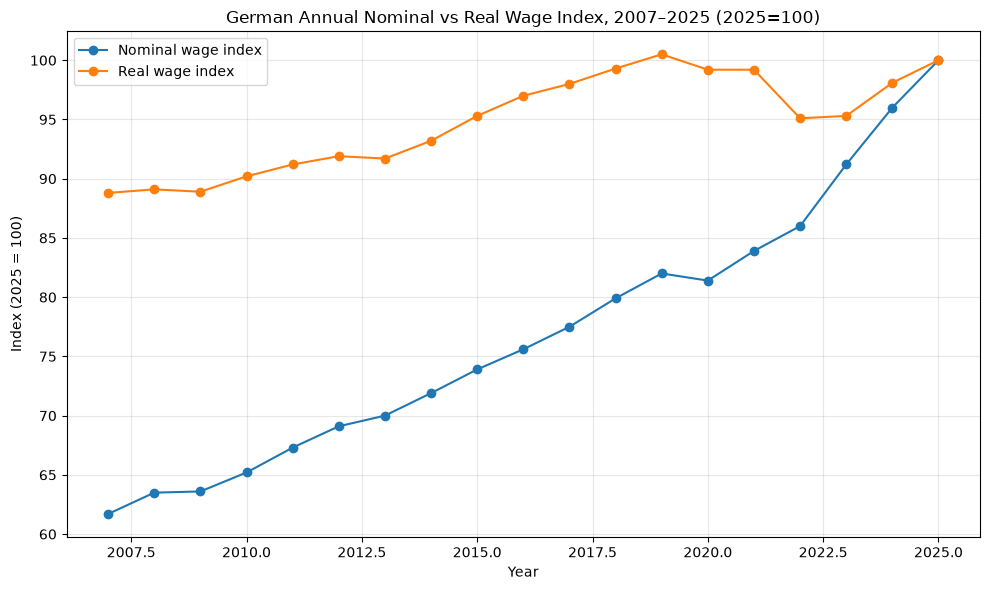

In [101]:


plt.figure(figsize=(10, 6))

plt.plot(
    df_raw["year"],
    df_raw["nominal_wage_index"],
    marker="o",
    label="Nominal wage index"
)

plt.plot(
    df_raw["year"],
    df_raw["real_wage_index"],
    marker="o",
    label="Real wage index"
)

plt.title("German Annual Nominal vs Real Wage Index, 2007–2025 (2025=100)")
plt.xlabel("Year")
plt.ylabel("Index (2025 = 100)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../figures/annualy_nominal_vs_real_wage_2007_2025.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Missing values:
real_wage_growth       2
nominal_wage_growth    1
dtype: int64

Rows with missing growth data:
    year  real_wage_growth  nominal_wage_growth
0   2007               NaN                  NaN
14  2021               NaN                  3.1

Data types:
year                     int64
real_wage_growth       float64
nominal_wage_growth    float64
dtype: object

Annual growth data:
 year  real_wage_growth  nominal_wage_growth
 2007               NaN                  NaN
 2008               0.3                  2.9
 2009              -0.2                  0.2
 2010               1.5                  2.5
 2011               1.1                  3.2
 2012               0.8                  2.7
 2013              -0.2                  1.3
 2014               1.6                  2.7
 2015               2.3                  2.8
 2016               1.8                  2.3
 2017               1.0                  2.5
 2018               1.3                  3.1
 2019              

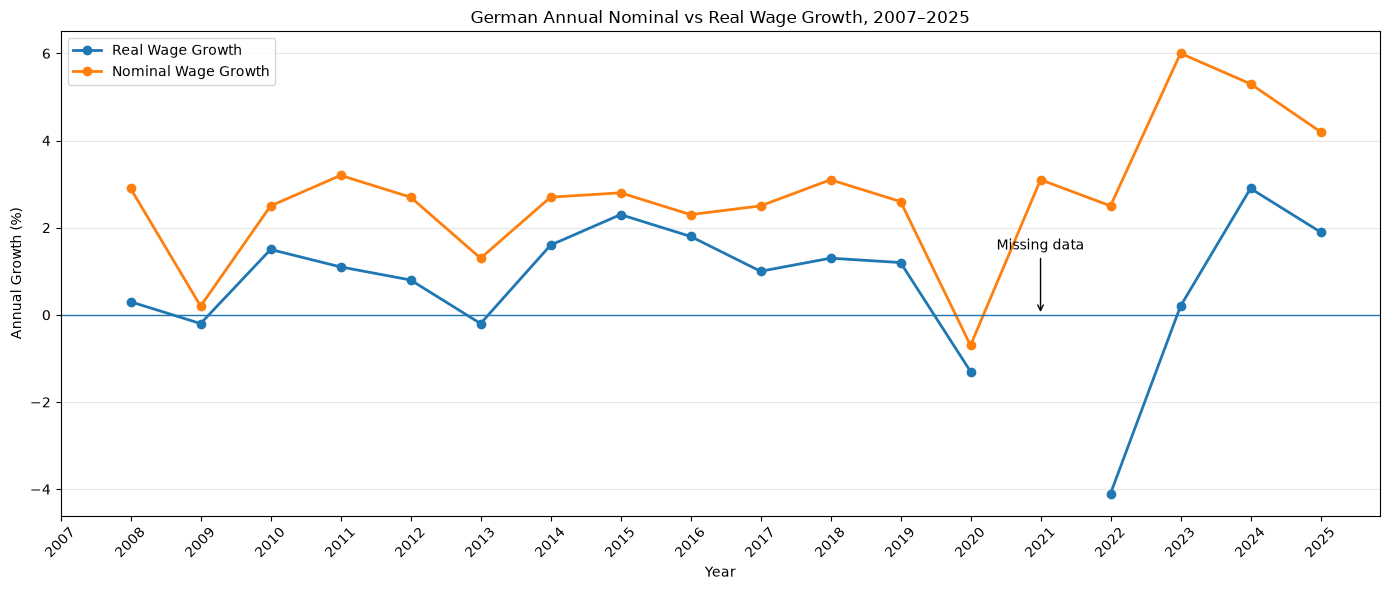

In [102]:
# ============================================
# Annual Wage Growth: 2007–2025
# ============================================
# ============================================
# Check and Plot Annual Wage Growth: 2007–2025
# ============================================

import matplotlib.pyplot as plt
import pandas as pd

# --------------------------------------------
# 1. Check missing values
# --------------------------------------------

annual_growth = df_raw[
    [
        "year",
        "real_wage_growth",
        "nominal_wage_growth"
    ]
].copy()

print("Missing values:")
print(
    annual_growth[
        ["real_wage_growth", "nominal_wage_growth"]
    ].isna().sum()
)

print("\nRows with missing growth data:")
print(
    annual_growth[
        annual_growth[
            ["real_wage_growth", "nominal_wage_growth"]
        ].isna().any(axis=1)
    ]
)

# --------------------------------------------
# 2. Check the data types
# --------------------------------------------

print("\nData types:")
print(annual_growth.dtypes)

# --------------------------------------------
# 3. Check the full annual growth dataset
# --------------------------------------------

print("\nAnnual growth data:")
print(annual_growth.to_string(index=False))

# --------------------------------------------
# 4. Plot
# --------------------------------------------

plt.figure(figsize=(14, 6))

plt.plot(
    annual_growth["year"],
    annual_growth["real_wage_growth"],
    marker="o",
    linewidth=2,
    label="Real Wage Growth"
)

plt.plot(
    annual_growth["year"],
    annual_growth["nominal_wage_growth"],
    marker="o",
    linewidth=2,
    label="Nominal Wage Growth"
)

# Zero reference line
plt.axhline(
    y=0,
    linewidth=1
)

# Mark missing real wage growth in 2021
plt.annotate(
    "Missing data",
    xy=(2021, 0),
    xytext=(2021, 1.5),
    ha="center",
    arrowprops=dict(arrowstyle="->")
)

# Labels
plt.title(
    "German Annual Nominal vs Real Wage Growth, 2007–2025"
)

plt.xlabel("Year")
plt.ylabel("Annual Growth (%)")

plt.xticks(
    annual_growth["year"],
    rotation=45
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.legend()

plt.tight_layout()

# Save
plt.savefig(
    "../figures/annual_nominal_vs_real_wage_growth_2007_2025.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [103]:
# ============================================================
# 2. Quarterly Wage Analysis
#
# This section analyzes short-term changes in wages in Germany
# using quarterly nominal and real wage index data.
#
# The quarterly data provides a more detailed view of wage
# developments than annual data and allows changes around major
# economic events to be examined more closely.
#
# Research focus:
# - Quarterly nominal wage development
# - Quarterly real wage development
# - Year-over-year wage growth
# - Changes in purchasing power
# - Short-term wage fluctuations
# - Wage development around major economic shocks
#
# Major periods of interest:
# - 2008–2009: Global Financial Crisis
# - 2020: COVID-19 pandemic
# - 2022–2023: Energy and inflation shock
#
# Data source:
# Destatis GENESIS, Table 62361-0010(2022-2025)
#
# Coverage:
# Germany, 2007–2025
# ============================================================


# ------------------------------------------------------------
# 1. Import libraries
# ------------------------------------------------------------

import io
import zipfile
import requests
import pandas as pd


# ------------------------------------------------------------
# 2. API settings
# ------------------------------------------------------------

BASE_URL = "https://genesis.destatis.de/genesisWS/rest/2020/"

headers = {
    "Content-Type": "application/x-www-form-urlencoded",
    "username": token
}


# ------------------------------------------------------------
# 3. Download quarterly wage data from Destatis
# ------------------------------------------------------------

response = requests.post(
    BASE_URL + "data/tablefile",
    headers=headers,
    data={
        "name": "62361-0010",
        "area": "all",
        "format": "ffcsv",
        "language": "en",
        "compress": "true"
    }
)

print("Status:", response.status_code)
print("Content-Type:", response.headers.get("Content-Type"))

response.raise_for_status()


# ------------------------------------------------------------
# 4. Read the ZIP file directly in memory
# ------------------------------------------------------------

zip_file = zipfile.ZipFile(
    io.BytesIO(response.content)
)

print("Files in ZIP:")
print(zip_file.namelist())


# ------------------------------------------------------------
# 5. Read CSV from ZIP
# ------------------------------------------------------------

csv_file = zip_file.open(
    zip_file.namelist()[0]
)

quarterly = pd.read_csv(
    csv_file,
    delimiter=";",
    decimal=",",
    na_values=["...", ".", "-", "/", "x"]
)


# ------------------------------------------------------------
# 6. Inspect the downloaded data
# ------------------------------------------------------------

print("\nShape:")
print(quarterly.shape)

print("\nColumns:")
print(quarterly.columns.tolist())

print("\nFirst 5 rows:")
display(quarterly.head())

Status: 200
Content-Type: application/zip
Files in ZIP:
['62361-0010_1790693966282_en_flat.csv']

Shape:
(72, 17)

Columns:
['statistics_code', 'statistics_label', 'time_code', 'time_label', 'time', '1_variable_code', '1_variable_label', '1_variable_attribute_code', '1_variable_attribute_label', '2_variable_code', '2_variable_label', '2_variable_attribute_code', '2_variable_attribute_label', 'value', 'value_unit', 'value_variable_code', 'value_variable_label']

First 5 rows:


,statistics_code,statistics_label,time_code,time_label,time,1_variable_code,1_variable_label,1_variable_attribute_code,1_variable_attribute_label,2_variable_code,2_variable_label,2_variable_attribute_code,2_variable_attribute_label,value,value_unit,value_variable_code,value_variable_label
0,62361,Earnings survey,JAHR,Year,2022,QUARTG,Quarters,QUART4,Quarter 4,DINSG,Germany,DG,Germany,93.9,2025=100,VST075,Nominal wage index
1,62361,Earnings survey,JAHR,Year,2022,QUARTG,Quarters,QUART4,Quarter 4,DINSG,Germany,DG,Germany,2.8,%,VST075,in
2,62361,Earnings survey,JAHR,Year,2022,QUARTG,Quarters,QUART4,Quarter 4,DINSG,Germany,DG,Germany,100.8,2025=100,VST074,Real wage index
3,62361,Earnings survey,JAHR,Year,2022,QUARTG,Quarters,QUART4,Quarter 4,DINSG,Germany,DG,Germany,-5.4,%,VST074,in
4,62361,Earnings survey,JAHR,Year,2022,QUARTG,Quarters,QUART3,Quarter 3,DINSG,Germany,DG,Germany,82.1,2025=100,VST075,Nominal wage index


In [104]:
# ------------------------------------------------------------
# 7. Filter wage index data
# ------------------------------------------------------------

quarterly_index = quarterly[
    quarterly["value_unit"] == "2025=100"
].copy()

print(quarterly_index[
    [
        "time",
        "1_variable_attribute_label",
        "value_variable_label",
        "value"
    ]
].head(10))


    time 1_variable_attribute_label value_variable_label  value
0   2022                  Quarter 4   Nominal wage index   93.9
2   2022                  Quarter 4      Real wage index  100.8
4   2022                  Quarter 3   Nominal wage index   82.1
6   2022                  Quarter 3      Real wage index   90.0
8   2022                  Quarter 2   Nominal wage index   86.5
10  2022                  Quarter 2      Real wage index   96.3
12  2022                  Quarter 1   Nominal wage index   81.5
14  2022                  Quarter 1      Real wage index   93.4
16  2026                  Quarter 2   Nominal wage index  105.2
18  2026                  Quarter 2      Real wage index  102.7


In [105]:
# ------------------------------------------------------------
# 8. Reshape and prepare quarterly wage index data
# ------------------------------------------------------------

# Keep only index values
quarterly_index = quarterly[
    (quarterly["value_unit"] == "2025=100") &
    (quarterly["time"].between(2007, 2025))
].copy()

# Convert value to numeric
quarterly_index["value"] = pd.to_numeric(
    quarterly_index["value"],
    errors="coerce"
)

# Keep only the columns needed
quarterly_index = quarterly_index[
    [
        "time",
        "1_variable_attribute_label",
        "value_variable_label",
        "value"
    ]
].copy()

# Reshape from long format to wide format
quarterly_index = quarterly_index.pivot(
    index=["time", "1_variable_attribute_label"],
    columns="value_variable_label",
    values="value"
).reset_index()

quarterly_index.columns.name = None

# Rename columns
quarterly_index = quarterly_index.rename(
    columns={
        "time": "Year",
        "1_variable_attribute_label": "Quarter",
        "Nominal wage index": "Nominal_Wage_Index",
        "Real wage index": "Real_Wage_Index"
    }
)

# Create chronological quarter number
quarter_order = {
    "Quarter 1": 1,
    "Quarter 2": 2,
    "Quarter 3": 3,
    "Quarter 4": 4
}

quarterly_index["Quarter_Number"] = (
    quarterly_index["Quarter"].map(quarter_order)
)

# Sort chronologically
quarterly_index = quarterly_index.sort_values(
    ["Year", "Quarter_Number"]
).reset_index(drop=True)

# Create period label
quarterly_index["Period"] = (
    quarterly_index["Year"].astype(str)
    + " "
    + quarterly_index["Quarter"].str.replace("Quarter ", "Q")
)

print(quarterly_index.head(10))

   Year    Quarter  Nominal_Wage_Index  Real_Wage_Index  Quarter_Number  \
0  2022  Quarter 1                81.5             93.4               1   
1  2022  Quarter 2                86.5             96.3               2   
2  2022  Quarter 3                82.1             90.0               3   
3  2022  Quarter 4                93.9            100.8               4   
4  2023  Quarter 1                86.1             91.1               1   
5  2023  Quarter 2                92.2             96.4               2   
6  2023  Quarter 3                87.3             90.6               3   
7  2023  Quarter 4                99.0            102.7               4   
8  2024  Quarter 1                91.6             94.5               1   
9  2024  Quarter 2                97.2             99.3               2   

    Period  
0  2022 Q1  
1  2022 Q2  
2  2022 Q3  
3  2022 Q4  
4  2023 Q1  
5  2023 Q2  
6  2023 Q3  
7  2023 Q4  
8  2024 Q1  
9  2024 Q2  


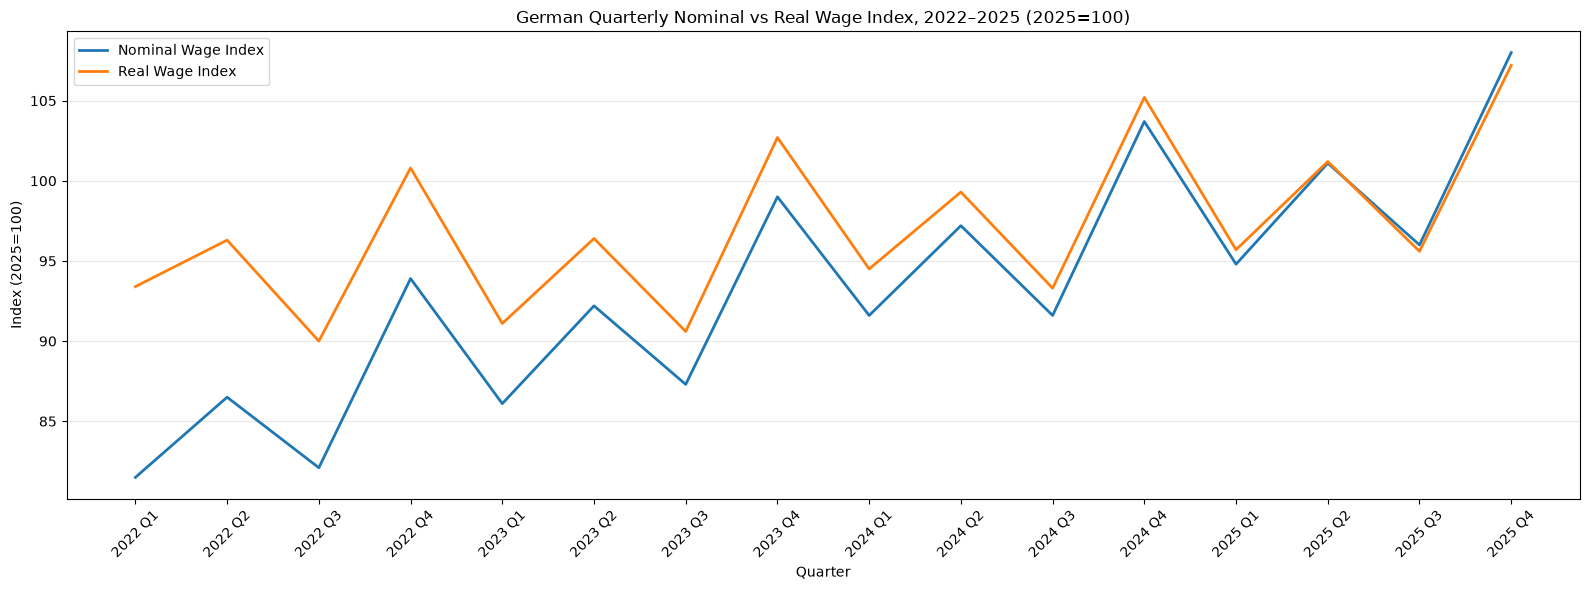

In [106]:
# ------------------------------------------------------------
# 9. Quarterly Nominal vs Real Wage Index（2022-2025）
# ------------------------------------------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(16, 6))

plt.plot(
    quarterly_index["Period"],
    quarterly_index["Nominal_Wage_Index"],
    label="Nominal Wage Index",
    linewidth=2
)

plt.plot(
    quarterly_index["Period"],
    quarterly_index["Real_Wage_Index"],
    label="Real Wage Index",
    linewidth=2
)

plt.title(
    "German Quarterly Nominal vs Real Wage Index, 2022–2025 (2025=100)"
)

plt.xlabel("Quarter")
plt.ylabel("Index (2025=100)")

plt.legend()

# Show every quarter
plt.xticks(
    range(len(quarterly_index)),
    quarterly_index["Period"],
    rotation=45
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "../figures/quarterly_nominal_vs_real_wage_2022_2025.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [107]:
# ============================================================
# 10. Historical Quarterly Wage Data: 2007–2021
#
# Source:
# Destatis / Statistische Bibliothek
#
# This section loads the historical quarterly wage index data
# and prepares it for combination with the current GENESIS data.
# ============================================================

from pathlib import Path

raw_path = Path("../data/raw")

excel_file = raw_path / "reallohnindex_2021.xlsx"

print("Reading:", excel_file)

xls = pd.ExcelFile(excel_file)

print("Available sheets:")
print(xls.sheet_names)

Reading: ../data/raw/reallohnindex_2021.xlsx
Available sheets:
['Deckblatt', 'Inhalt', 'Erläuterungen', '1 ', '2.1 ', '2.2 ', '3.1 ', '3.2 ']


In [108]:
# ============================================================
# 11. Inspect historical wage data sheets
# ============================================================

sheet_21 = pd.read_excel(
    excel_file,
    sheet_name="2.1 "
)

sheet_22 = pd.read_excel(
    excel_file,
    sheet_name="2.2 "
)

print("Sheet 2.1:")
display(sheet_21.head(15))

print("\nSheet 2.2:")
display(sheet_22.head(15))

Sheet 2.1:


,2. Nominallohnindex nach Wirtschaftszweigen,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,Unnamed: 32,Unnamed: 33,Unnamed: 34,Unnamed: 35,Unnamed: 36,Unnamed: 37,Unnamed: 38,Unnamed: 39,Unnamed: 40,Unnamed: 41,Unnamed: 42,Unnamed: 43,Unnamed: 44,Unnamed: 45,Unnamed: 46,Unnamed: 47,Unnamed: 48,Unnamed: 49,Unnamed: 50,Unnamed: 51,Unnamed: 52,Unnamed: 53,Unnamed: 54,Unnamed: 55,Unnamed: 56,Unnamed: 57,Unnamed: 58,Unnamed: 59,Unnamed: 60,Unnamed: 61,Unnamed: 62,Unnamed: 63,Unnamed: 64,Unnamed: 65,Unnamed: 66,Unnamed: 67,Unnamed: 68,Unnamed: 69,Unnamed: 70,Unnamed: 71,Unnamed: 72,Unnamed: 73,Unnamed: 74,Unnamed: 75
0,Arbeitnehmer im Produzierenden Gewerbe und i...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.1 Indizes (2015 = 100),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Wirtschaftszweig,2007.0,2008.0,2009.0,2010.0,2011.0,2012.0,2013.0,2014.0,2015.0,2016.0,NaN,NaN,NaN,NaN,NaN,1.,2.,3.,4.,1.,2.,3.,4.,1.,2.,3.,4.,1.,2.,3.,4.,1.,2.,3.,4.,1.,2.,3.,4.,1.,2.,3.,4.,1.,2.,3.,4.,1.,2.,3.,4.,1.,2.,3.,4.,1.,2.,3.,4.,1.,2.,3.,4.,1.,2.,3.,4.,1.,2.,3.,4.,1.,2.,3.,4.
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.0,2018.0,2019.0,2020.0,2021,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2007,2007,2007,2007,2008,2008,2008,2008,2009,2009,2009,2009,2010,2010,2010,2010,2011,2011,2011,2011,2012,2012,2012,2012,2013,2013,2013,2013,2014,2014,2014,2014,2015,2015,2015,2015,2016,2016,2016,2016,2017,2017,2017,2017,2018,2018,2018,2018,2019,2019,2019,2019,2020,2020,2020,2020,2021,2021,2021,2021
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,B-S Produzierendes Gewerbe und Dienstleistungs...,83.4,85.9,86.1,88.3,91.2,93.5,94.8,97.4,100.0,102.3,104.9,108.1,110.9,110.1,113.5,79.1,83.9,79.5,91.4,81.3,87.1,81.8,93.8,81.8,86.5,82.2,94,83.2,89.2,84.2,96.7,86.4,92.8,86.7,99,88.2,95.1,89.3,101.7,89.5,96.4,90.5,103,91.9,98.9,92.9,105.8,94.3,102.1,95.2,108.4,97,104.1,97.4,110.9,99.6,107.1,99.8,113.3,102.3,109.8,103.4,117,104.9,113.1,106.9,119.3,107.1,108.6,105.5,119.5,106.4,114.6,109.6,123.8
8,B-N Produzierendes Gewerbe und wirtschaftliche...,83.7,86.3,85.4,88.2,91.5,93.8,94.8,97.3,100.0,102.2,104.8,10


Sheet 2.2:


,2. Nominallohnindex nach Wirtschaftszweigen,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,Unnamed: 32,Unnamed: 33,Unnamed: 34,Unnamed: 35,Unnamed: 36,Unnamed: 37,Unnamed: 38,Unnamed: 39,Unnamed: 40,Unnamed: 41,Unnamed: 42,Unnamed: 43,Unnamed: 44,Unnamed: 45,Unnamed: 46,Unnamed: 47,Unnamed: 48,Unnamed: 49,Unnamed: 50,Unnamed: 51,Unnamed: 52,Unnamed: 53,Unnamed: 54,Unnamed: 55,Unnamed: 56,Unnamed: 57,Unnamed: 58,Unnamed: 59,Unnamed: 60,Unnamed: 61,Unnamed: 62,Unnamed: 63,Unnamed: 64,Unnamed: 65,Unnamed: 66,Unnamed: 67,Unnamed: 68,Unnamed: 69,Unnamed: 70,Unnamed: 71,Unnamed: 72,Unnamed: 73,Unnamed: 74,Unnamed: 75
0,Arbeitnehmer im Produzierenden Gewerbe und i...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.2 Veränderung gegenüber dem Vorjahreszeitr...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Wirtschaftszweig,2007,2008.0,2009.0,2010.0,2011.0,2012.0,2013.0,2014.0,2015.0,2016.0,NaN,NaN,NaN,NaN,NaN,1.,2.,3.,4.,1.,2.,3.,4.,1.,2.,3.,4.,1.,2.,3.,4.,1.,2.,3.,4.,1.,2.,3.,4.,1.,2.,3.,4.,1.,2.,3.,4.,1.,2.,3.,4.,1.,2.,3.,4.,1.,2.,3.,4.,1.,2.,3.,4.,1.,2.,3.,4.,1.,2.,3.,4.,1.,2.,3.,4.
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.0,2018.0,2019.0,2020.0,2021,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal,Quartal
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2007,2007,2007,2007,2008,2008,2008,2008,2009,2009,2009,2009,2010,2010,2010,2010,2011,2011,2011,2011,2012,2012,2012,2012,2013,2013,2013,2013,2014,2014,2014,2014,2015,2015,2015,2015,2016,2016,2016,2016,2017,2017,2017,2017,2018,2018,2018,2018,2019,2019,2019,2019,2020,2020,2020,2020,2021,2021,2021,2021
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,B-S Produzierendes Gewerbe und Dienstleistungs...,-,3.0,0.2,2.6,3.3,2.5,1.4,2.7,2.7,2.3,2.5,3.1,2.6,-0.7,3.1,-,-,-,-,2.8,3.8,2.9,2.6,0.6,-0.7,0.5,0.2,1.7,3.1,2.4,2.9,3.8,4,3,2.4,2.1,2.5,3,2.7,1.5,1.4,1.3,1.3,2.7,2.6,2.7,2.7,2.6,3.2,2.5,2.5,2.9,2,2.3,2.3,"2,7r",2.9,2.5,2.2,2.7,2.5,3.6,3.3,2.5,3,3.4,2,2.1,-4,-1.3,0.2,-0.7,5.5,3.9,3.6
8,B-N Produzierendes Gewerbe und wirtschaftliche...,-,3.1,-1.0,3.3,3.7,2.5,1.1,2.6,2.8,2.2,2.5,3.1,2.4,-2.0,3.5,-,-,-,-,3.4,3.8,3,2.3,-0.7,-2.1,-0.7,-0.6,1.6,3.9,3.1,3.9,4.6,4.9,3.3,2.5,2.2,2.7,2.9,2.3,1,

In [109]:
# ============================================================
# 12. Inspect Real Wage Index sheets
# ============================================================

sheet_31 = pd.read_excel(
    excel_file,
    sheet_name="3.1 "
)

sheet_32 = pd.read_excel(
    excel_file,
    sheet_name="3.2 "
)

print("Sheet 3.1:")
display(sheet_31.head(15))

print("\nSheet 3.2:")
display(sheet_32.head(15))

Sheet 3.1:


,3. Nominallohnindex nach verschiedenen Gliederungsarten,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14
0,Arbeitnehmer im Produzierenden Gewerbe und i...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3.1 Indizes (2015 = 100),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Berichtszeitraum,NaN,Insgesamt,Nach Gebietsstand,NaN,Nach Beschäftigungsart,NaN,NaN,Nach Geschlecht,NaN,Nach Leistungsgruppen1,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,Früheres Bundesgebiet,Neue Länder,Vollzeit-beschäftigte,Teilzeit-beschäftigte,Geringfügig Beschäftigte,Frauen,Männer,Arbeitnehmer in leitender Stellung,Herausgehobene Fachkräfte,Fachkräfte,Angelernte Arbeitnehmer,Ungelernte Arbeitnehmer
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2007,JD,83.4,83.7,80.7,83.7,81.5,80.1,82.3,84,79.2,83.2,85.4,85.9,84.1
7,2008,JD,85.9,86.2,83.8,86.2,84.2,81.3,84.7,86.5,82.8,85.8,87.5,87.7,86
8,2009,JD,86.1,86.2,85.1,86.2,86.1,81.2,86.2,86,83.6,86.5,87.4,86.4,85.1
9,2010,JD,88.3,88.5,87,88.5,87.7,82.9,88,88.5,85.7,88.7,89.6,89.2,88.5



Sheet 3.2:


,3. Nominallohnindex nach verschiedenen Gliederungsarten,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14
0,Arbeitnehmer im Produzierenden Gewerbe und i...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3.2 Veränderung gegenüber dem Vorjahreszeitr...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Berichtszeitraum,NaN,Insgesamt,Nach Gebietsstand,NaN,Nach Beschäftigungsart,NaN,NaN,Nach Geschlecht,NaN,Nach Leistungsgruppen1,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,Früheres Bundesgebiet,Neue Länder,Vollzeit-beschäftigte,Teilzeit-beschäftigte,Geringfügig Beschäftigte,Frauen,Männer,Arbeitnehmer in leitender Stellung,Herausgehobene Fachkräfte,Fachkräfte,Angelernte Arbeitnehmer,Ungelernte Arbeitnehmer
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2007,JD,-,-,-,-,-,-,-,-,-,-,-,-,-
7,2008,JD,3,3,3.8,3,3.3,1.5,2.9,3,4.5,3.1,2.5,2.1,2.3
8,2009,JD,0.2,0,1.6,0,2.3,-0.1,1.8,-0.6,1,0.8,-0.1,-1.5,-1
9,2010,JD,2.6,2.7,2.2,2.7,1.9,2.1,2.1,2.9,2.5,2.5,2.5,3.2,4


In [110]:
# ============================================================
# 12. Inspect Sheet 1
# ============================================================

sheet_1 = pd.read_excel(
    excel_file,
    sheet_name="1 "
)

display(sheet_1.head(20))

,"1. Reallohnindex, Nominallohnindex sowie Verbraucherpreisindex",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Berichtszeitraum,NaN,Reallohnindex,NaN,Nominallohnindex,NaN,Verbraucherpreisindex1,NaN
3,NaN,NaN,2015 = 100,Veränderung zum Vorjahreszeitraum in Prozent,2015 = 100,Veränderung zum Vorjahreszeitraum in Prozent,2015 = 100,Veränderung zum Vorjahreszeitraum in Prozent
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2007,1. Quartal,89.3,-,79.1,-,88.6,1.7
6,NaN,2. Quartal,94,-,83.9,-,89.3,1.9
7,NaN,3. Quartal,88.5,-,79.5,-,89.8,2.3
8,NaN,4. Quartal,100.9,-,91.4,-,90.6,3.2
9,2008,1. Quartal,89.1,-0.2,81.3,2.8,91.2,2.9


In [111]:
# ============================================================
# 13. Extract Historical Quarterly Wage Data: 2007–2021
#
# Source:
# Destatis / Statistische Bibliothek
#
# The Excel file contains quarterly data for:
# - Real wage index
# - Nominal wage index
# - Consumer Price Index (CPI)
#
# The original index base is 2015 = 100.
# ============================================================

# Read the historical Excel sheet
historical = pd.read_excel(
    excel_file,
    sheet_name="1 ",
    header=None
)

# Remove the header rows and keep the 8 relevant columns
historical = historical.iloc[6:, [0, 1, 2, 3, 4, 5, 6, 7]].copy()

# Assign clear column names
historical.columns = [
    "Year",
    "Quarter",
    "Real_Wage_Index",
    "Real_Wage_Growth",
    "Nominal_Wage_Index",
    "Nominal_Wage_Growth",
    "CPI_Index",
    "CPI_Growth"
]

# The year is only shown for the first quarter of each year
# in the original Excel file.
# Forward-fill the year for the remaining quarters.
historical["Year"] = historical["Year"].ffill()

# Convert index and growth columns to numeric values.
# Invalid or non-numeric values are converted to NaN.
numeric_columns = [
    "Year",
    "Real_Wage_Index",
    "Real_Wage_Growth",
    "Nominal_Wage_Index",
    "Nominal_Wage_Growth",
    "CPI_Index",
    "CPI_Growth"
]

for col in numeric_columns:
    historical[col] = pd.to_numeric(
        historical[col],
        errors="coerce"
    )

# Convert German quarter labels into Q1–Q4.
quarter_map = {
    "1. Quartal": "Q1",
    "2. Quartal": "Q2",
    "3. Quartal": "Q3",
    "4. Quartal": "Q4"
}

historical["Quarter"] = (
    historical["Quarter"]
    .astype(str)
    .str.strip()
    .map(quarter_map)
)

# Remove rows where the quarter could not be identified.
historical = historical[
    historical["Quarter"].notna()
].copy()

# Create a numeric quarter variable for chronological sorting.
quarter_number_map = {
    "Q1": 1,
    "Q2": 2,
    "Q3": 3,
    "Q4": 4
}

historical["Quarter_Number"] = (
    historical["Quarter"]
    .map(quarter_number_map)
)

# Create a combined period label.
# Example: 2007 Q1, 2007 Q2, ..., 2021 Q4
historical["Period"] = (
    historical["Year"].astype(int).astype(str)
    + " "
    + historical["Quarter"]
)

# Sort the data chronologically.
historical = historical.sort_values(
    ["Year", "Quarter_Number"]
).reset_index(drop=True)

# Display the first and last observations
# to verify that the data was imported correctly.
display(historical.head(10))
display(historical.tail(10))

# Check the covered period and number of observations.
print(
    "Years:",
    historical["Year"].min(),
    "to",
    historical["Year"].max()
)

print("Rows:", len(historical))

,Year,Quarter,Real_Wage_Index,Real_Wage_Growth,Nominal_Wage_Index,Nominal_Wage_Growth,CPI_Index,CPI_Growth,Quarter_Number,Period
0,2007.0,Q1,89.3,NaN,79.1,NaN,88.6,1.7,1,2007 Q1
1,2007.0,Q2,94.0,NaN,83.9,NaN,89.3,1.9,2,2007 Q2
2,2007.0,Q3,88.5,NaN,79.5,NaN,89.8,2.3,3,2007 Q3
3,2007.0,Q4,100.9,NaN,91.4,NaN,90.6,3.2,4,2007 Q4
4,2008.0,Q1,89.1,-0.2,81.3,2.8,91.2,2.9,1,2008 Q1
5,2008.0,Q2,94.8,0.9,87.1,3.8,91.9,2.9,2,2008 Q2
6,2008.0,Q3,88.3,-0.2,81.8,2.9,92.6,3.1,3,2008 Q3
7,2008.0,Q4,102.0,1.1,93.8,2.6,92.0,1.5,4,2008 Q4
8,2009.0,Q1,88.9,-0.2,81.8,0.6,92.0,0.9,1,2009 Q1
9,2009.0,Q2,93.9,-0.9,86.5,-0.7,92.1,0.2,2,2009 Q2


,Year,Quarter,Real_Wage_Index,Real_Wage_Growth,Nominal_Wage_Index,Nominal_Wage_Growth,CPI_Index,CPI_Growth,Quarter_Number,Period
50,2019.0,Q3,100.8,1.9,106.9,3.4,106.1,1.5,3,2019 Q3
51,2019.0,Q4,112.9,0.7,119.3,2.0,105.7,1.2,4,2019 Q4
52,2020.0,Q1,101.5,0.4,107.1,2.1,105.5,1.6,1,2020 Q1
53,2020.0,Q2,102.3,-4.7,108.6,-4.0,106.2,0.8,2,2020 Q2
54,2020.0,Q3,99.5,-1.3,105.5,-1.3,106.0,-0.1,3,2020 Q3
55,2020.0,Q4,113.3,0.4,119.5,0.2,105.5,-0.2,4,2020 Q4
56,2021.0,Q1,99.5,-2.0,106.4,-0.7,106.9,1.3,1,2021 Q1
57,2021.0,Q2,105.4,3.0,114.6,5.5,108.7,2.4,2,2021 Q2
58,2021.0,Q3,99.5,0.0,109.6,3.9,110.1,3.9,3,2021 Q3
59,2021.0,Q4,111.7,-1.4,123.8,3.6,110.8,5.0,4,2021 Q4


Years: 2007.0 to 2021.0
Rows: 60


In [112]:
# ============================================================
# 14. Validate Historical Quarterly Data
# ============================================================

# Check the number of observations for each year.
year_counts = historical.groupby("Year").size()

print("Number of quarters per year:")
print(year_counts)

# Check for missing values in the key index columns.
print("\nMissing values:")
print(
    historical[
        [
            "Year",
            "Quarter",
            "Real_Wage_Index",
            "Nominal_Wage_Index",
            "CPI_Index"
        ]
    ].isna().sum()
)

# Check the first and last period.
print("\nFirst period:", historical["Period"].iloc[0])
print("Last period:", historical["Period"].iloc[-1])

# Display the last 8 observations.
display(
    historical[
        [
            "Year",
            "Quarter",
            "Real_Wage_Index",
            "Nominal_Wage_Index",
            "CPI_Index",
            "Period"
        ]
    ].tail(8)
)

Number of quarters per year:
Year
2007.0    4
2008.0    4
2009.0    4
2010.0    4
2011.0    4
2012.0    4
2013.0    4
2014.0    4
2015.0    4
2016.0    4
2017.0    4
2018.0    4
2019.0    4
2020.0    4
2021.0    4
dtype: int64

Missing values:
Year                  0
Quarter               0
Real_Wage_Index       0
Nominal_Wage_Index    0
CPI_Index             0
dtype: int64

First period: 2007 Q1
Last period: 2021 Q4


,Year,Quarter,Real_Wage_Index,Nominal_Wage_Index,CPI_Index,Period
52,2020.0,Q1,101.5,107.1,105.5,2020 Q1
53,2020.0,Q2,102.3,108.6,106.2,2020 Q2
54,2020.0,Q3,99.5,105.5,106.0,2020 Q3
55,2020.0,Q4,113.3,119.5,105.5,2020 Q4
56,2021.0,Q1,99.5,106.4,106.9,2021 Q1
57,2021.0,Q2,105.4,114.6,108.7,2021 Q2
58,2021.0,Q3,99.5,109.6,110.1,2021 Q3
59,2021.0,Q4,111.7,123.8,110.8,2021 Q4


In [113]:
# ============================================================
# 15. Compare Historical and Current Quarterly Series
#
# Historical data: 2015 = 100
# Current GENESIS data: 2025 = 100
#
# We inspect the transition around 2021–2022 before
# deciding how to link the two series.
# ============================================================

print("Historical data: 2021")
display(
    historical[
        historical["Year"] == 2021
    ][
        [
            "Year",
            "Quarter",
            "Real_Wage_Index",
            "Nominal_Wage_Index",
            "CPI_Index",
            "Real_Wage_Growth",
            "Nominal_Wage_Growth"
        ]
    ]
)

print("\nCurrent GENESIS data: 2022")
display(
    quarterly_index[
        quarterly_index["Year"] == 2022
    ][
        [
            "Year",
            "Quarter",
            "Real_Wage_Index",
            "Nominal_Wage_Index"
        ]
    ]
)

Historical data: 2021


,Year,Quarter,Real_Wage_Index,Nominal_Wage_Index,CPI_Index,Real_Wage_Growth,Nominal_Wage_Growth
56,2021.0,Q1,99.5,106.4,106.9,-2.0,-0.7
57,2021.0,Q2,105.4,114.6,108.7,3.0,5.5
58,2021.0,Q3,99.5,109.6,110.1,0.0,3.9
59,2021.0,Q4,111.7,123.8,110.8,-1.4,3.6



Current GENESIS data: 2022


,Year,Quarter,Real_Wage_Index,Nominal_Wage_Index
0,2022,Quarter 1,93.4,81.5
1,2022,Quarter 2,96.3,86.5
2,2022,Quarter 3,90.0,82.1
3,2022,Quarter 4,100.8,93.9


In [114]:
# ============================================================
# 16. Create Continuous Quarterly Wage Index
#
# Historical data: 2015 = 100
# Current GENESIS data: 2025 = 100
#
# To make the series comparable, both periods are rebased
# to 2021 Q4 = 100.
#
# This creates a normalized analytical index.
# It is NOT an official Destatis index base.
# ============================================================

# ------------------------------------------------------------
# 1. Prepare historical data
# ------------------------------------------------------------

historical_linked = historical[
    [
        "Year",
        "Quarter",
        "Quarter_Number",
        "Period",
        "Real_Wage_Index",
        "Nominal_Wage_Index"
    ]
].copy()

# ------------------------------------------------------------
# 2. Prepare current GENESIS data
# ------------------------------------------------------------

current_linked = quarterly_index[
    [
        "Year",
        "Quarter",
        "Quarter_Number",
        "Period",
        "Real_Wage_Index",
        "Nominal_Wage_Index"
    ]
].copy()

# Convert current quarter labels to Q1–Q4
current_linked["Quarter"] = (
    current_linked["Quarter"]
    .str.replace("Quarter ", "Q")
)

# Recreate period label
current_linked["Period"] = (
    current_linked["Year"].astype(int).astype(str)
    + " "
    + current_linked["Quarter"]
)

# ------------------------------------------------------------
# 3. Find the 2021 Q4 reference values
# ------------------------------------------------------------

historical_reference = historical_linked[
    (historical_linked["Year"] == 2021) &
    (historical_linked["Quarter"] == "Q4")
].iloc[0]

current_reference = current_linked[
    (current_linked["Year"] == 2022) &
    (current_linked["Quarter"] == "Q1")
].iloc[0]

print("Historical 2021 Q4:")
print(
    "Real wage:",
    historical_reference["Real_Wage_Index"]
)
print(
    "Nominal wage:",
    historical_reference["Nominal_Wage_Index"]
)

print("\nCurrent 2022 Q1:")
print(
    "Real wage:",
    current_reference["Real_Wage_Index"]
)
print(
    "Nominal wage:",
    current_reference["Nominal_Wage_Index"]
)

# ------------------------------------------------------------
# 4. Rebase historical series to 2021 Q4 = 100
# ------------------------------------------------------------

historical_linked["Real_Wage_Index_Normalized"] = (
    historical_linked["Real_Wage_Index"]
    / historical_reference["Real_Wage_Index"]
    * 100
)

historical_linked["Nominal_Wage_Index_Normalized"] = (
    historical_linked["Nominal_Wage_Index"]
    / historical_reference["Nominal_Wage_Index"]
    * 100
)

# ------------------------------------------------------------
# 5. Rebase current series to 2021 Q4 = 100
#
# First calculate the implied 2021 Q4 value using
# the 2022 Q1 year-over-year growth rates.
# ------------------------------------------------------------

# Get the official 2022 Q1 YoY growth rates
q1_2022_growth = historical[
    (historical["Year"] == 2021) &
    (historical["Quarter"] == "Q1")
].iloc[0]

current_linked["Real_Wage_Index_Normalized"] = (
    current_linked["Real_Wage_Index"]
    / current_reference["Real_Wage_Index"]
    * 100
)

current_linked["Nominal_Wage_Index_Normalized"] = (
    current_linked["Nominal_Wage_Index"]
    / current_reference["Nominal_Wage_Index"]
    * 100
)

# ------------------------------------------------------------
# 6. Combine the two datasets
# ------------------------------------------------------------

quarterly_combined = pd.concat(
    [
        historical_linked,
        current_linked
    ],
    ignore_index=True
)

# Remove any duplicate observations
quarterly_combined = quarterly_combined.drop_duplicates(
    subset=["Year", "Quarter"]
)

# Sort chronologically
quarterly_combined = quarterly_combined.sort_values(
    ["Year", "Quarter_Number"]
).reset_index(drop=True)

# ------------------------------------------------------------
# 7. Keep only the formal analysis period
# ------------------------------------------------------------

quarterly_combined = quarterly_combined[
    quarterly_combined["Year"].between(2007, 2025)
].copy()

# ------------------------------------------------------------
# 8. Display result
# ------------------------------------------------------------

display(
    quarterly_combined[
        [
            "Year",
            "Quarter",
            "Period",
            "Real_Wage_Index_Normalized",
            "Nominal_Wage_Index_Normalized"
        ]
    ].head(10)
)

print(
    "\nCoverage:",
    quarterly_combined["Period"].iloc[0],
    "to",
    quarterly_combined["Period"].iloc[-1]
)

print(
    "Observations:",
    len(quarterly_combined)
)

Historical 2021 Q4:
Real wage: 111.7
Nominal wage: 123.8

Current 2022 Q1:
Real wage: 93.4
Nominal wage: 81.5


,Year,Quarter,Period,Real_Wage_Index_Normalized,Nominal_Wage_Index_Normalized
0,2007.0,Q1,2007 Q1,79.946285,63.893376
1,2007.0,Q2,2007 Q2,84.153984,67.770598
2,2007.0,Q3,2007 Q3,79.230081,64.216478
3,2007.0,Q4,2007 Q4,90.331244,73.828756
4,2008.0,Q1,2008 Q1,79.767234,65.670436
5,2008.0,Q2,2008 Q2,84.870188,70.355412
6,2008.0,Q3,2008 Q3,79.051030,66.074313
7,2008.0,Q4,2008 Q4,91.316025,75.767367
8,2009.0,Q1,2009 Q1,79.588183,66.074313
9,2009.0,Q2,2009 Q2,84.064458,69.870759



Coverage: 2007 Q1 to 2025 Q4
Observations: 76


In [115]:
# ============================================================
# 17. Validate Combined Quarterly Wage Series
# ============================================================

# ------------------------------------------------------------
# 1. Check first 8 observations
# ------------------------------------------------------------

print("First 8 observations:")
display(
    quarterly_combined[
        [
            "Year",
            "Quarter",
            "Period",
            "Real_Wage_Index_Normalized",
            "Nominal_Wage_Index_Normalized"
        ]
    ].head(8)
)

# ------------------------------------------------------------
# 2. Check last 8 observations
# ------------------------------------------------------------

print("\nLast 8 observations:")
display(
    quarterly_combined[
        [
            "Year",
            "Quarter",
            "Period",
            "Real_Wage_Index_Normalized",
            "Nominal_Wage_Index_Normalized"
        ]
    ].tail(8)
)

# ------------------------------------------------------------
# 3. Check observations per year
# ------------------------------------------------------------

print("\nNumber of quarters per year:")

print(
    quarterly_combined
    .groupby("Year")
    .size()
)

# ------------------------------------------------------------
# 4. Check missing values
# ------------------------------------------------------------

print("\nMissing values:")

print(
    quarterly_combined[
        [
            "Year",
            "Quarter",
            "Real_Wage_Index_Normalized",
            "Nominal_Wage_Index_Normalized"
        ]
    ].isna().sum()
)

# ------------------------------------------------------------
# 5. Check coverage
# ------------------------------------------------------------

print(
    "\nCoverage:",
    quarterly_combined["Period"].iloc[0],
    "to",
    quarterly_combined["Period"].iloc[-1]
)

print(
    "Total observations:",
    len(quarterly_combined)
)

# ------------------------------------------------------------
# 6. Inspect the transition around 2021–2022
# ------------------------------------------------------------

print("\n2021–2022 transition:")

display(
    quarterly_combined[
        quarterly_combined["Year"].isin([2021, 2022])
    ][
        [
            "Year",
            "Quarter",
            "Period",
            "Real_Wage_Index_Normalized",
            "Nominal_Wage_Index_Normalized"
        ]
    ]
)

First 8 observations:


,Year,Quarter,Period,Real_Wage_Index_Normalized,Nominal_Wage_Index_Normalized
0,2007.0,Q1,2007 Q1,79.946285,63.893376
1,2007.0,Q2,2007 Q2,84.153984,67.770598
2,2007.0,Q3,2007 Q3,79.230081,64.216478
3,2007.0,Q4,2007 Q4,90.331244,73.828756
4,2008.0,Q1,2008 Q1,79.767234,65.670436
5,2008.0,Q2,2008 Q2,84.870188,70.355412
6,2008.0,Q3,2008 Q3,79.051030,66.074313
7,2008.0,Q4,2008 Q4,91.316025,75.767367



Last 8 observations:


,Year,Quarter,Period,Real_Wage_Index_Normalized,Nominal_Wage_Index_Normalized
68,2024.0,Q1,2024 Q1,101.177730,112.392638
69,2024.0,Q2,2024 Q2,106.316916,119.263804
70,2024.0,Q3,2024 Q3,99.892934,112.392638
71,2024.0,Q4,2024 Q4,112.633833,127.239264
72,2025.0,Q1,2025 Q1,102.462527,116.319018
73,2025.0,Q2,2025 Q2,108.351178,124.049080
74,2025.0,Q3,2025 Q3,102.355460,117.791411
75,2025.0,Q4,2025 Q4,114.775161,132.515337



Number of quarters per year:
Year
2007.0    4
2008.0    4
2009.0    4
2010.0    4
2011.0    4
2012.0    4
2013.0    4
2014.0    4
2015.0    4
2016.0    4
2017.0    4
2018.0    4
2019.0    4
2020.0    4
2021.0    4
2022.0    4
2023.0    4
2024.0    4
2025.0    4
dtype: int64

Missing values:
Year                             0
Quarter                          0
Real_Wage_Index_Normalized       0
Nominal_Wage_Index_Normalized    0
dtype: int64

Coverage: 2007 Q1 to 2025 Q4
Total observations: 76

2021–2022 transition:


,Year,Quarter,Period,Real_Wage_Index_Normalized,Nominal_Wage_Index_Normalized
56,2021.0,Q1,2021 Q1,89.077887,85.945073
57,2021.0,Q2,2021 Q2,94.359893,92.568659
58,2021.0,Q3,2021 Q3,89.077887,88.529887
59,2021.0,Q4,2021 Q4,100.000000,100.000000
60,2022.0,Q1,2022 Q1,100.000000,100.000000
61,2022.0,Q2,2022 Q2,103.104925,106.134969
62,2022.0,Q3,2022 Q3,96.359743,100.736196
63,2022.0,Q4,2022 Q4,107.922912,115.214724


In [116]:
# ============================================================
# 18. Link Historical and Current Quarterly Wage Indexes
# ============================================================
#
# Problem:
#
# Historical Destatis data:
#     2007–2021
#     Index base = 2015 = 100
#
# Current Destatis GENESIS data:
#     2022–2025
#     Index base = 2025 = 100
#
# These two index levels cannot be directly concatenated because
# they use different base years.
#
# Solution:
#
# We create an analytical index where:
#
#     2021 Q4 = 100
#
# This allows us to show the entire 2007–2025 period on one
# continuous scale.
#
# IMPORTANT:
# This "2021 Q4 = 100" series is an analytical normalization.
# It is NOT an official Destatis index base.
# ============================================================


# ------------------------------------------------------------
# 1. Get the historical 2021 Q4 reference values
# ------------------------------------------------------------
#
# Historical series:
#     Base = 2015 = 100
#
# We use 2021 Q4 as the reference point for the historical data.

historical_reference = historical[
    (historical["Year"] == 2021) &
    (historical["Quarter"] == "Q4")
].iloc[0]

historical_real_q4 = historical_reference["Real_Wage_Index"]
historical_nominal_q4 = historical_reference["Nominal_Wage_Index"]

print("Historical 2021 Q4 reference:")
print("Real wage index:", historical_real_q4)
print("Nominal wage index:", historical_nominal_q4)


# ------------------------------------------------------------
# 2. Rebase the historical series
# ------------------------------------------------------------
#
# Formula:
#
#     normalized index
#     =
#     original index / 2021 Q4 index × 100
#
# Therefore:
#
#     2021 Q4 = 100
#
# Example:
#
#     Historical real wage 2007 Q1
#     = 89.3
#
#     89.3 / 111.7 × 100
#     ≈ 79.95
#
# This means that the real wage index in 2007 Q1 was about
# 79.95 relative to 2021 Q4 = 100.

historical_linked = historical.copy()

historical_linked["Real_Wage_Index_Normalized"] = (
    historical_linked["Real_Wage_Index"]
    / historical_real_q4
    * 100
)

historical_linked["Nominal_Wage_Index_Normalized"] = (
    historical_linked["Nominal_Wage_Index"]
    / historical_nominal_q4
    * 100
)


# ------------------------------------------------------------
# 3. Get the current GENESIS 2022 Q1 values
# ------------------------------------------------------------
#
# Current GENESIS data:
#     Base = 2025 = 100
#
# We need to calculate how this new series should be positioned
# relative to the historical series.
#
# The important information is the official year-over-year
# growth rate for 2022 Q1.
#
# This tells us how 2022 Q1 compares with 2021 Q1.


# Find the 2022 Q1 observations in the current dataset.

current_2022_q1 = quarterly_index[
    (quarterly_index["Year"] == 2022) &
    (quarterly_index["Quarter"] == "Quarter 1")
].iloc[0]

print("\nCurrent GENESIS 2022 Q1:")
print("Real wage index:", current_2022_q1["Real_Wage_Index"])
print("Nominal wage index:", current_2022_q1["Nominal_Wage_Index"])

Historical 2021 Q4 reference:
Real wage index: 111.7
Nominal wage index: 123.8

Current GENESIS 2022 Q1:
Real wage index: 93.4
Nominal wage index: 81.5


In [117]:
# ============================================
# Step 19: Create analytical linking factors
# ============================================
#
# Why do we need a linking factor?
#
# The historical quarterly series (2007-2021)
# uses 2015 = 100 as its index base.
#
# The current GENESIS series (2022 onward)
# uses 2025 = 100 as its index base.
#
# Therefore, we cannot directly concatenate
# the two index series.
#
# We use the official 2022 Q1 year-over-year
# growth rates to establish a mathematical link
# between the old and new series.
#
# This is an analytical normalization for this
# project, not an official Destatis rebasing.
# ============================================


# --------------------------------------------
# 1. Extract official 2022 Q1 YoY growth rates
# --------------------------------------------

growth_2022_q1 = quarterly[
    (quarterly["time"] == 2022) &
    (quarterly["1_variable_attribute_label"] == "Quarter 1") &
    (
        quarterly["value_variable_code"].isin(
            ["VST074", "VST075"]
        )
    ) &
    (quarterly["value_unit"] == "%")
].copy()


growth_2022_q1["value"] = pd.to_numeric(
    growth_2022_q1["value"],
    errors="coerce"
)


display(
    growth_2022_q1[
        [
            "time",
            "1_variable_attribute_label",
            "value_variable_code",
            "value_variable_label",
            "value",
            "value_unit"
        ]
    ]
)

,time,1_variable_attribute_label,value_variable_code,value_variable_label,value,value_unit
13,2022,Quarter 1,VST075,in,3.8,%
15,2022,Quarter 1,VST074,in,-0.8,%


In [118]:
# ============================================================
# 19.1 Inspect the Current GENESIS Data Columns
# ============================================================

print("Columns in quarterly dataframe:")
print(quarterly.columns.tolist())

Columns in quarterly dataframe:
['statistics_code', 'statistics_label', 'time_code', 'time_label', 'time', '1_variable_code', '1_variable_label', '1_variable_attribute_code', '1_variable_attribute_label', '2_variable_code', '2_variable_label', '2_variable_attribute_code', '2_variable_attribute_label', 'value', 'value_unit', 'value_variable_code', 'value_variable_label']


In [119]:
# ============================================================
# 19.2 Get Official 2022 Q1 Year-over-Year Growth Rates
# ============================================================
#
# In the GENESIS dataset:
#
#   VST074 = Real wage change vs previous-year quarter
#   VST075 = Nominal wage change vs previous-year quarter
#
# The relevant column is:
#
#   value_variable_code
#
# NOT "code".
# ============================================================


# Select the two official YoY wage-growth variables
# for 2022 Q1.

growth_2022_q1 = quarterly[
    (quarterly["time"] == 2022) &
    (quarterly["1_variable_attribute_label"] == "Quarter 1") &
    (
        quarterly["value_variable_code"].isin(
            ["VST074", "VST075"]
        )
    )
].copy()


# Display the result

display(
    growth_2022_q1[
        [
            "time",
            "1_variable_attribute_label",
            "value_variable_code",
            "value_variable_label",
            "value",
            "value_unit"
        ]
    ]
)

,time,1_variable_attribute_label,value_variable_code,value_variable_label,value,value_unit
12,2022,Quarter 1,VST075,Nominal wage index,81.5,2025=100
13,2022,Quarter 1,VST075,in,3.8,%
14,2022,Quarter 1,VST074,Real wage index,93.4,2025=100
15,2022,Quarter 1,VST074,in,-0.8,%


In [120]:
# ============================================
# Step 19.3: Calculate linking factors
# ============================================
#
# Historical series:
#   2015 = 100
#
# Current series:
#   2025 = 100
#
# We use the official 2022 Q1 YoY growth rates
# to estimate what the 2022 Q1 index would have
# been on the historical scale.
#
# Then we compare that value with the current
# 2022 Q1 index to obtain a linking factor.
#
# This is an analytical normalization for this
# project, not an official Destatis rebasing.
# ============================================


# --------------------------------------------
# 1. Get historical 2021 Q1 values
# --------------------------------------------

historical_2021_q1 = historical[
    (historical["Year"] == 2021) &
    (historical["Quarter"] == "Q1")
].iloc[0]


historical_2021_q1_real = (
    historical_2021_q1["Real_Wage_Index"]
)

historical_2021_q1_nominal = (
    historical_2021_q1["Nominal_Wage_Index"]
)


# --------------------------------------------
# 2. Official 2022 Q1 YoY growth rates
# --------------------------------------------

real_growth_2022_q1 = -0.8
nominal_growth_2022_q1 = 3.8


# --------------------------------------------
# 3. Calculate implied 2022 Q1 values
#    on the historical scale
# --------------------------------------------

implied_2022_q1_real = (
    historical_2021_q1_real
    * (1 + real_growth_2022_q1 / 100)
)

implied_2022_q1_nominal = (
    historical_2021_q1_nominal
    * (1 + nominal_growth_2022_q1 / 100)
)


# --------------------------------------------
# 4. Get current 2022 Q1 index values
#    from the 2025=100 series
# --------------------------------------------

current_2022_q1 = quarterly_index[
    (quarterly_index["Year"] == 2022) &
    (quarterly_index["Quarter"] == "Quarter 1")
].iloc[0]


current_2022_q1_real = (
    current_2022_q1["Real_Wage_Index"]
)

current_2022_q1_nominal = (
    current_2022_q1["Nominal_Wage_Index"]
)


# --------------------------------------------
# 5. Calculate linking factors
# --------------------------------------------

real_link_factor = (
    implied_2022_q1_real
    / current_2022_q1_real
)

nominal_link_factor = (
    implied_2022_q1_nominal
    / current_2022_q1_nominal
)


# --------------------------------------------
# 6. Display all values for validation
# --------------------------------------------

print("Historical 2021 Q1 real index:",
      historical_2021_q1_real)

print("Implied 2022 Q1 real index:",
      implied_2022_q1_real)

print("Current 2022 Q1 real index:",
      current_2022_q1_real)

print("Real link factor:",
      real_link_factor)

print()

print("Historical 2021 Q1 nominal index:",
      historical_2021_q1_nominal)

print("Implied 2022 Q1 nominal index:",
      implied_2022_q1_nominal)

print("Current 2022 Q1 nominal index:",
      current_2022_q1_nominal)

print("Nominal link factor:",
      nominal_link_factor)

Historical 2021 Q1 real index: 99.5
Implied 2022 Q1 real index: 98.704
Current 2022 Q1 real index: 93.4
Real link factor: 1.0567880085653103

Historical 2021 Q1 nominal index: 106.4
Implied 2022 Q1 nominal index: 110.4432
Current 2022 Q1 nominal index: 81.5
Nominal link factor: 1.3551312883435582


In [121]:
# ============================================
# Step 20: Calculate YoY wage growth
# ============================================

import pandas as pd

# --------------------------------------------
# 1. Historical series: 2007–2021
# --------------------------------------------

historical_growth = historical.copy()

historical_growth["Real_Wage_Growth_YoY"] = (
    historical_growth["Real_Wage_Index"]
    .pct_change(periods=4) * 100
)

historical_growth["Nominal_Wage_Growth_YoY"] = (
    historical_growth["Nominal_Wage_Index"]
    .pct_change(periods=4) * 100
)


# --------------------------------------------
# 2. New series: 2022–2025
# --------------------------------------------

current_growth = quarterly_index.copy()

current_growth["Real_Wage_Growth_YoY"] = (
    current_growth["Real_Wage_Index"]
    .pct_change(periods=4) * 100
)

current_growth["Nominal_Wage_Growth_YoY"] = (
    current_growth["Nominal_Wage_Index"]
    .pct_change(periods=4) * 100
)


# --------------------------------------------
# 3. Keep only the useful columns
# --------------------------------------------

historical_growth = historical_growth[
    [
        "Year",
        "Quarter",
        "Quarter_Number",
        "Period",
        "Real_Wage_Growth_YoY",
        "Nominal_Wage_Growth_YoY"
    ]
]

current_growth = current_growth[
    [
        "Year",
        "Quarter",
        "Quarter_Number",
        "Period",
        "Real_Wage_Growth_YoY",
        "Nominal_Wage_Growth_YoY"
    ]
]


# --------------------------------------------
# 4. Combine into ONE final table
# --------------------------------------------

quarterly_growth = pd.concat(
    [historical_growth, current_growth],
    ignore_index=True
)

quarterly_growth = quarterly_growth.sort_values(
    ["Year", "Quarter_Number"]
).reset_index(drop=True)


# --------------------------------------------
# 5. Remove duplicate periods
# --------------------------------------------

quarterly_growth = quarterly_growth.drop_duplicates(
    subset=["Year", "Quarter"],
    keep="last"
)


# --------------------------------------------
# 6. Check result
# --------------------------------------------

print(quarterly_growth.head())
print(quarterly_growth.tail(10))

     Year Quarter  Quarter_Number   Period  Real_Wage_Growth_YoY  \
0  2007.0      Q1               1  2007 Q1                   NaN   
1  2007.0      Q2               2  2007 Q2                   NaN   
2  2007.0      Q3               3  2007 Q3                   NaN   
3  2007.0      Q4               4  2007 Q4                   NaN   
4  2008.0      Q1               1  2008 Q1             -0.223964   

   Nominal_Wage_Growth_YoY  
0                      NaN  
1                      NaN  
2                      NaN  
3                      NaN  
4                  2.78129  
      Year    Quarter  Quarter_Number   Period  Real_Wage_Growth_YoY  \
66  2023.0  Quarter 3               3  2023 Q3              0.666667   
67  2023.0  Quarter 4               4  2023 Q4              1.884921   
68  2024.0  Quarter 1               1  2024 Q1              3.732162   
69  2024.0  Quarter 2               2  2024 Q2              3.008299   
70  2024.0  Quarter 3               3  2024 Q3           

In [122]:
quarterly_growth[
    quarterly_growth["Year"] == 2022
]

,Year,Quarter,Quarter_Number,Period,Real_Wage_Growth_YoY,Nominal_Wage_Growth_YoY
60,2022.0,Quarter 1,1,2022 Q1,NaN,NaN
61,2022.0,Quarter 2,2,2022 Q2,NaN,NaN
62,2022.0,Quarter 3,3,2022 Q3,NaN,NaN
63,2022.0,Quarter 4,4,2022 Q4,NaN,NaN


In [123]:
# ============================================
# Step 20b: Fill official 2022 YoY growth rates
# ============================================

official_2022 = {
    "2022 Q1": {
        "Real_Wage_Growth_YoY": -0.8,
        "Nominal_Wage_Growth_YoY": 3.8
    },
    "2022 Q2": {
        "Real_Wage_Growth_YoY": -4.1,
        "Nominal_Wage_Growth_YoY": 2.4
    },
    "2022 Q3": {
        "Real_Wage_Growth_YoY": -5.4,
        "Nominal_Wage_Growth_YoY": 1.6
    },
    "2022 Q4": {
        "Real_Wage_Growth_YoY": -5.4,
        "Nominal_Wage_Growth_YoY": 2.8
    }
}


# Fill the 2022 rows
for period, values in official_2022.items():

    mask = quarterly_growth["Period"] == period

    quarterly_growth.loc[
        mask, "Real_Wage_Growth_YoY"
    ] = values["Real_Wage_Growth_YoY"]

    quarterly_growth.loc[
        mask, "Nominal_Wage_Growth_YoY"
    ] = values["Nominal_Wage_Growth_YoY"]


# Check 2022
print(
    quarterly_growth[
        quarterly_growth["Year"] == 2022
    ]
)

      Year    Quarter  Quarter_Number   Period  Real_Wage_Growth_YoY  \
60  2022.0  Quarter 1               1  2022 Q1                  -0.8   
61  2022.0  Quarter 2               2  2022 Q2                  -4.1   
62  2022.0  Quarter 3               3  2022 Q3                  -5.4   
63  2022.0  Quarter 4               4  2022 Q4                  -5.4   

    Nominal_Wage_Growth_YoY  
60                      3.8  
61                      2.4  
62                      1.6  
63                      2.8  


In [124]:
# ============================================
# Step 20c: Final check
# ============================================

print("Data range:")
print(
    quarterly_growth["Period"].iloc[0],
    "to",
    quarterly_growth["Period"].iloc[-1]
)

print("\nNumber of observations:")
print(len(quarterly_growth))

print("\nMissing values:")
print(
    quarterly_growth[
        ["Real_Wage_Growth_YoY", "Nominal_Wage_Growth_YoY"]
    ].isna().sum()
)

print("\n2021–2023 transition:")
print(
    quarterly_growth[
        quarterly_growth["Year"].isin([2021, 2022, 2023])
    ][
        [
            "Period",
            "Real_Wage_Growth_YoY",
            "Nominal_Wage_Growth_YoY"
        ]
    ].to_string(index=False)
)

Data range:
2007 Q1 to 2025 Q4

Number of observations:
76

Missing values:
Real_Wage_Growth_YoY       4
Nominal_Wage_Growth_YoY    4
dtype: int64

2021–2023 transition:
 Period  Real_Wage_Growth_YoY  Nominal_Wage_Growth_YoY
2021 Q1             -1.970443                -0.653595
2021 Q2              3.030303                 5.524862
2021 Q3              0.000000                 3.886256
2021 Q4             -1.412180                 3.598326
2022 Q1             -0.800000                 3.800000
2022 Q2             -4.100000                 2.400000
2022 Q3             -5.400000                 1.600000
2022 Q4             -5.400000                 2.800000
2023 Q1             -2.462527                 5.644172
2023 Q2              0.103842                 6.589595
2023 Q3              0.666667                 6.333739
2023 Q4              1.884921                 5.431310


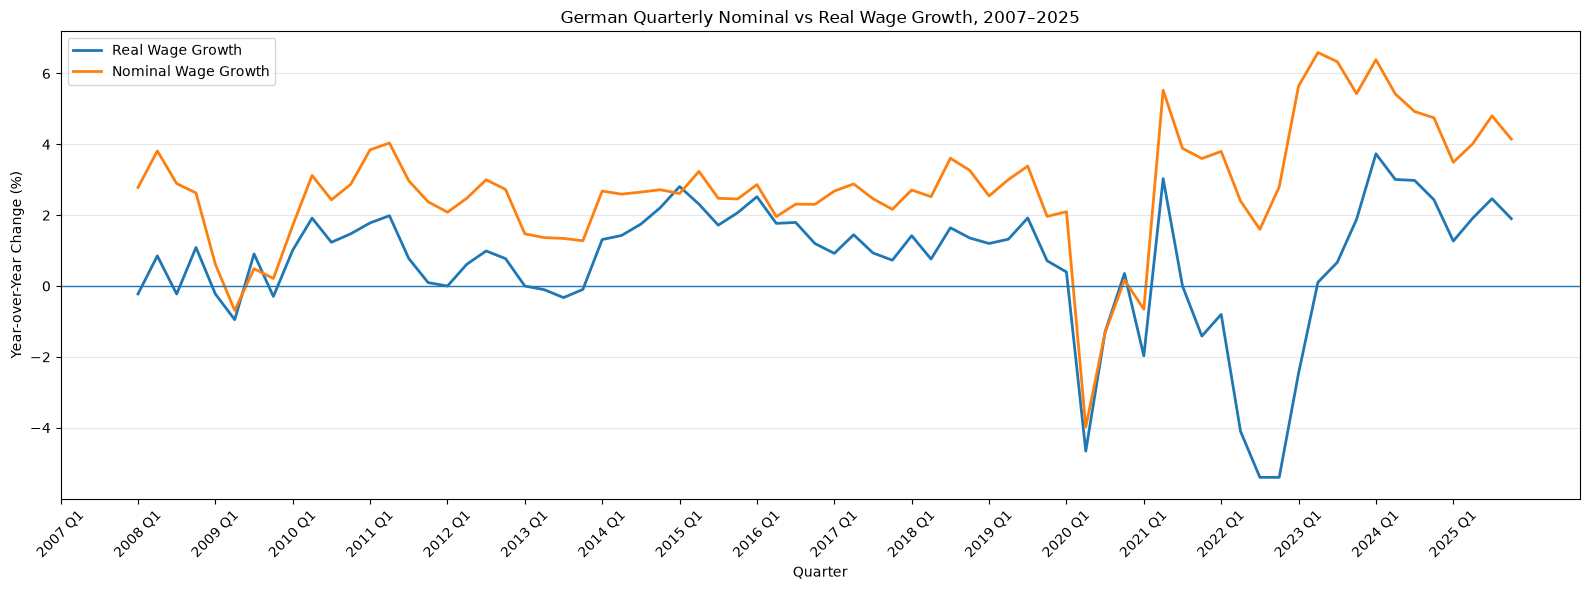

In [125]:
# ============================================
# Step 21: Plot quarterly wage growth
# ============================================

import matplotlib.pyplot as plt

plt.figure(figsize=(16, 6))

plt.plot(
    quarterly_growth["Period"],
    quarterly_growth["Real_Wage_Growth_YoY"],
    label="Real Wage Growth",
    linewidth=2
)

plt.plot(
    quarterly_growth["Period"],
    quarterly_growth["Nominal_Wage_Growth_YoY"],
    label="Nominal Wage Growth",
    linewidth=2
)

plt.axhline(
    0,
    linewidth=1
)

plt.title("German Quarterly Nominal vs Real Wage Growth, 2007–2025")
plt.xlabel("Quarter")
plt.ylabel("Year-over-Year Change (%)")

# Show every 4th quarter
plt.xticks(
    range(0, len(quarterly_growth), 4),
    quarterly_growth["Period"].iloc[::4],
    rotation=45
)

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../figures/quarterly_nominal_vs_real_wage_growth_2007_2025_2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

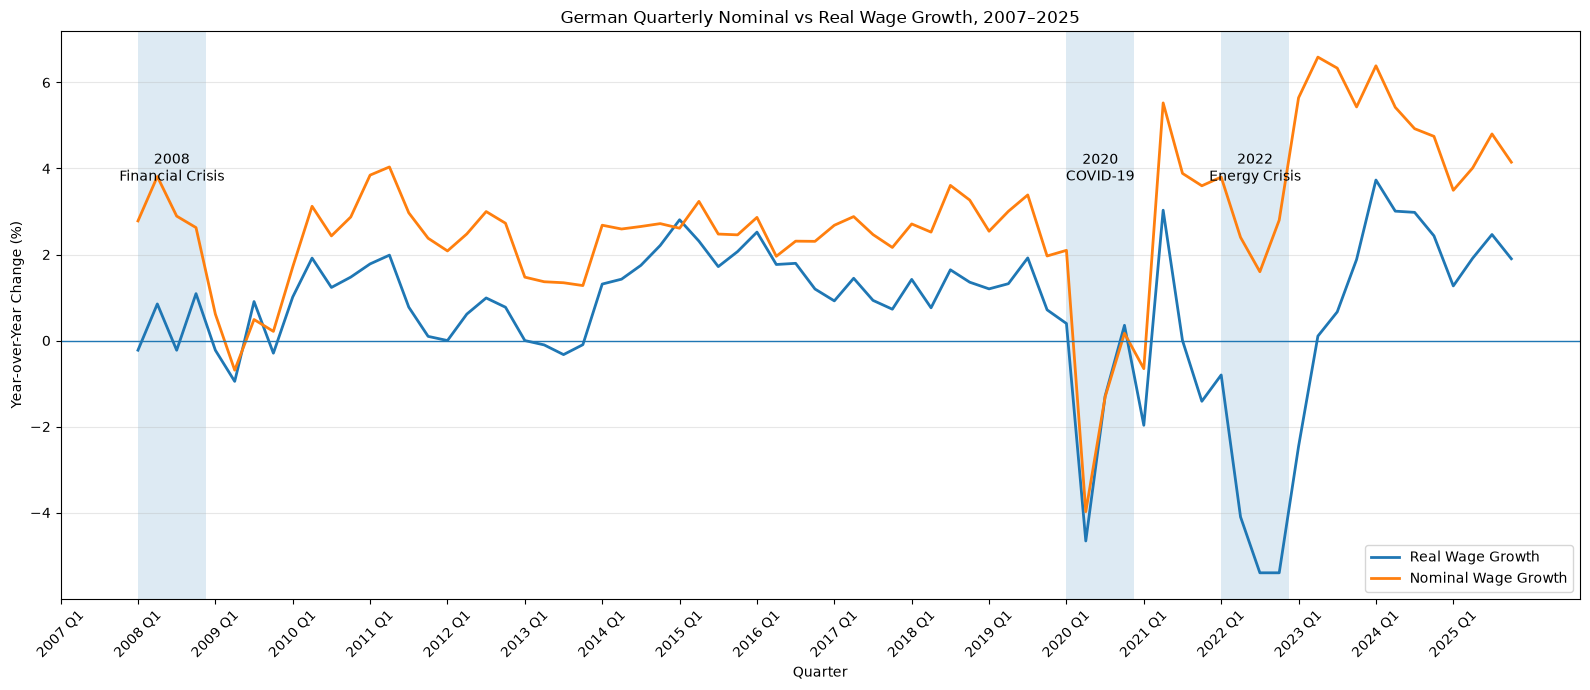

In [134]:
# ============================================
# Step 22: Plot Quarterly Wage Growth
#          with Major Economic Shocks
# ============================================

import matplotlib.pyplot as plt

plt.figure(figsize=(16, 7))

# --------------------------------------------
# Plot wage growth
# --------------------------------------------

plt.plot(
    quarterly_growth["Period"],
    quarterly_growth["Real_Wage_Growth_YoY"],
    label="Real Wage Growth",
    linewidth=2
)

plt.plot(
    quarterly_growth["Period"],
    quarterly_growth["Nominal_Wage_Growth_YoY"],
    label="Nominal Wage Growth",
    linewidth=2
)

# Zero reference line
plt.axhline(
    0,
    linewidth=1
)

# --------------------------------------------
# Major Economic Shocks
# --------------------------------------------

ax = plt.gca()

# Financial Crisis: 2008
ax.axvspan(
    4,
    7.5,
    alpha=0.15
)

ax.text(
    5.75,
    4,
    "2008\nFinancial Crisis",
    ha="center",
    va="center",
    fontsize=10
)

# COVID-19: 2020
ax.axvspan(
    52,
    55.5,
    alpha=0.15
)

ax.text(
    53.75,
    4,
    "2020\nCOVID-19",
    ha="center",
    va="center",
    fontsize=10
)

# Energy Crisis: 2022
ax.axvspan(
    60,
    63.5,
    alpha=0.15
)

ax.text(
    61.75,
    4,
    "2022\nEnergy Crisis",
    ha="center",
    va="center",
    fontsize=10
)

# --------------------------------------------
# Labels and formatting
# --------------------------------------------

plt.title(
    "German Quarterly Nominal vs Real Wage Growth, 2007–2025"
)

plt.xlabel("Quarter")
plt.ylabel("Year-over-Year Change (%)")

# Show every 4th quarter
plt.xticks(
    range(0, len(quarterly_growth), 4),
    quarterly_growth["Period"].iloc[::4],
    rotation=45
)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

# Save
plt.savefig(
    "../figures/quarterly_nominal_vs_real_wage_growth_2007_2025_shocks.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [135]:
# ============================================
# Conclusion
# ============================================

# Die Nominallöhne in Deutschland zeigten von 2007 bis 2025
# insgesamt einen langfristigen Aufwärtstrend.
#
# Die Reallohnentwicklung verlief jedoch deutlich volatiler,
# da die Lohnentwicklung stark von der Inflation beeinflusst wird.
# Eine steigende Nominallohnentwicklung bedeutet daher nicht automatisch
# eine steigende Kaufkraft.
#
# Besonders deutlich zeigt sich dieser Zusammenhang im Jahr 2022:
# Trotz steigender Nominallöhne gingen die Reallöhne aufgrund
# der starken Inflation deutlich zurück.
# Die Differenz zwischen nominalem und realem Lohnwachstum
# verdeutlicht den Einfluss der Preisentwicklung auf die Kaufkraft.
#
# Auch die Quartalsdaten zeigen deutliche Veränderungen während
# wichtiger wirtschaftlicher Schocks, insbesondere während der
# Finanzkrise 2008, der COVID-19-Pandemie 2020 und der Energie-
# und Inflationskrise 2022.
#
# Ab 2023 begann sich das Reallohnwachstum wieder zu erholen.
# Besonders 2024 war durch ein starkes Reallohnwachstum gekennzeichnet,
# da die Nominallöhne weiter stiegen und der Inflationsdruck nachließ.
#
# Im Jahr 2025 blieb das Reallohnwachstum positiv, verlangsamte sich
# jedoch gegenüber dem starken Wachstum im Jahr 2024.
#
# Insgesamt zeigt die Analyse, dass die Entwicklung der Löhne
# nicht allein anhand der Nominallöhne bewertet werden sollte.
# Für die Beurteilung der tatsächlichen Kaufkraft ist es entscheidend,
# die Lohnentwicklung gemeinsam mit der Inflation und den
# gesamtwirtschaftlichen Entwicklungen zu betrachten.

In [126]:
# ============================================
# Check 2021 Quarterly Real Wage Growth
# ============================================

quarterly_growth[
    quarterly_growth["Period"].astype(str).str.startswith("2021")
][
    [
        "Period",
        "Real_Wage_Growth_YoY",
        "Nominal_Wage_Growth_YoY"
    ]
]

,Period,Real_Wage_Growth_YoY,Nominal_Wage_Growth_YoY
56,2021 Q1,-1.970443,-0.653595
57,2021 Q2,3.030303,5.524862
58,2021 Q3,0.000000,3.886256
59,2021 Q4,-1.412180,3.598326


In [127]:
# Check historical data columns
print(historical.columns.tolist())

['Year', 'Quarter', 'Real_Wage_Index', 'Real_Wage_Growth', 'Nominal_Wage_Index', 'Nominal_Wage_Growth', 'CPI_Index', 'CPI_Growth', 'Quarter_Number', 'Period']


In [128]:
# ============================================
# Check 2020–2021 Real Wage Index
# ============================================

historical[
    historical["Year"].isin([2020, 2021])
][
    [
        "Year",
        "Quarter",
        "Real_Wage_Index",
        "Real_Wage_Growth"
    ]
]


,Year,Quarter,Real_Wage_Index,Real_Wage_Growth
52,2020.0,Q1,101.5,0.4
53,2020.0,Q2,102.3,-4.7
54,2020.0,Q3,99.5,-1.3
55,2020.0,Q4,113.3,0.4
56,2021.0,Q1,99.5,-2.0
57,2021.0,Q2,105.4,3.0
58,2021.0,Q3,99.5,0.0
59,2021.0,Q4,111.7,-1.4


In [129]:
# ============================================
# Calculate 2021 Annual Real Wage Growth
# ============================================

annual_real_wage_index = (
    historical[
        historical["Year"].isin([2020, 2021])
    ]
    .groupby("Year")["Real_Wage_Index"]
    .mean()
)

real_wage_growth_2021 = (
    annual_real_wage_index.loc[2021]
    / annual_real_wage_index.loc[2020]
    - 1
) * 100

print("Average Real Wage Index:")
print(annual_real_wage_index)

print(
    f"\n2021 Annual Real Wage Growth: "
    f"{real_wage_growth_2021:.2f}%"
)

Average Real Wage Index:
Year
2020.0    104.150
2021.0    104.025
Name: Real_Wage_Index, dtype: float64

2021 Annual Real Wage Growth: -0.12%


In [130]:
# ============================================
# Fill Missing 2021 Real Wage Growth
# ============================================

# The annual dataset has a missing value for real_wage_growth in 2021.
# Since quarterly real wage index data are available for all four
# quarters of both 2020 and 2021, the 2021 annual real wage growth
# is calculated from the annual average of the quarterly real wage index.
#
# Formula:
# 2021 annual real wage growth =
# (average 2021 quarterly real wage index
#  / average 2020 quarterly real wage index - 1) * 100
#
# Based on the quarterly index data:
# 2020 average index = 104.150
# 2021 average index = 104.025
# Result = -0.12%, rounded to one decimal place to match
# the precision of the original annual dataset.

df_raw.loc[
    df_raw["year"] == 2021,
    "real_wage_growth"
] = round(real_wage_growth_2021, 1)

# Check the updated values
df_raw[
    df_raw["year"].isin([2020, 2021, 2022])
][
    [
        "year",
        "real_wage_growth",
        "nominal_wage_growth"
    ]
]

,year,real_wage_growth,nominal_wage_growth
13,2020,-1.3,-0.7
14,2021,-0.1,3.1
15,2022,-4.1,2.5


In [131]:
# ============================================
# Final Missing Value Check
# ============================================

# 2007 remains missing because it is the first year
# in the annual dataset and therefore has no previous
# year available for calculating annual growth.

print(
    df_raw[
        ["year", "real_wage_growth", "nominal_wage_growth"]
    ].isna().sum()
)

print("\nRemaining missing rows:")

print(
    df_raw[
        df_raw[
            ["real_wage_growth", "nominal_wage_growth"]
        ].isna().any(axis=1)
    ][
        ["year", "real_wage_growth", "nominal_wage_growth"]
    ]
)

year                   0
real_wage_growth       1
nominal_wage_growth    1
dtype: int64

Remaining missing rows:
   year  real_wage_growth  nominal_wage_growth
0  2007               NaN                  NaN


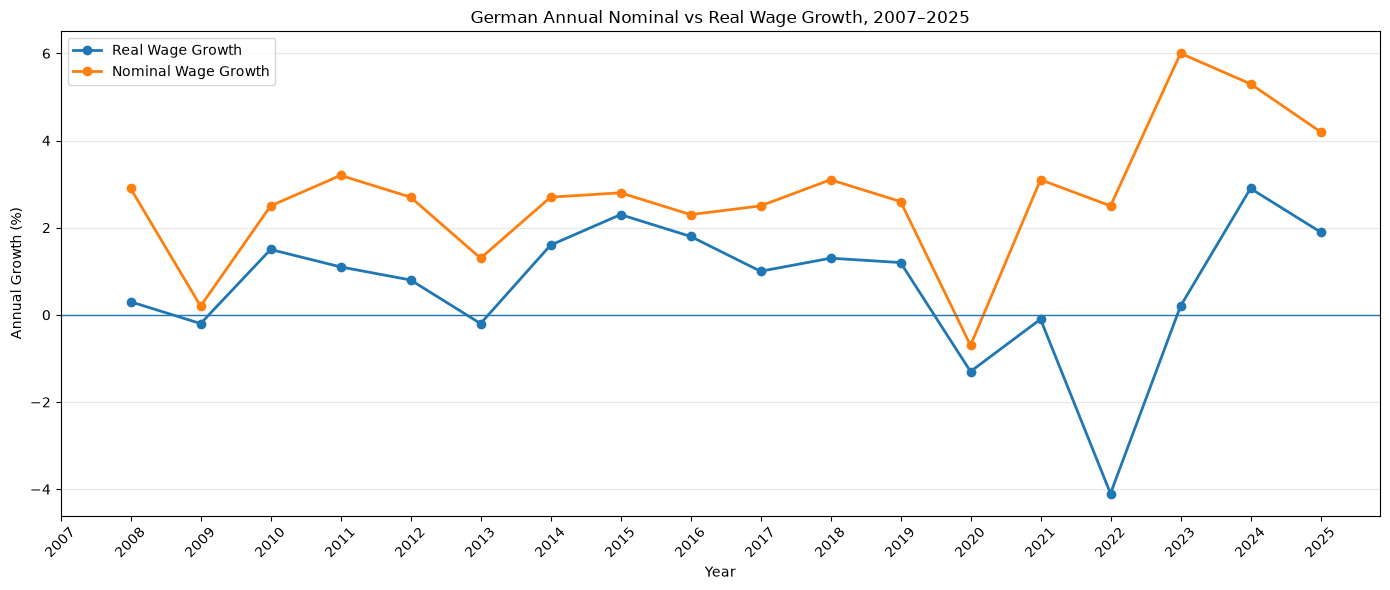

In [132]:
# ============================================
# Annual Wage Growth: 2007–2025
# ============================================

import matplotlib.pyplot as plt

annual_growth = df_raw[
    [
        "year",
        "real_wage_growth",
        "nominal_wage_growth"
    ]
].copy()

plt.figure(figsize=(14, 6))

plt.plot(
    annual_growth["year"],
    annual_growth["real_wage_growth"],
    marker="o",
    linewidth=2,
    label="Real Wage Growth"
)

plt.plot(
    annual_growth["year"],
    annual_growth["nominal_wage_growth"],
    marker="o",
    linewidth=2,
    label="Nominal Wage Growth"
)

plt.axhline(
    y=0,
    linewidth=1
)

plt.title(
    "German Annual Nominal vs Real Wage Growth, 2007–2025"
)

plt.xlabel("Year")
plt.ylabel("Annual Growth (%)")

plt.xticks(
    annual_growth["year"],
    rotation=45
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "../figures/annual_nominal_vs_real_wage_growth_2007_2025_complete.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()